# Lab 6: First-year first-time student dropout detection - Again
---

Grupo 3 \
Alexandre Rodrigues: 75545 \
Tiago Granja: 79845 \
Diogo Silva: 79828

Import libraries

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold

## First-year first-time student dropout

Last assignment we tackled the problem regarding first-year first-time student dropout with the use of deep learning techniques, more specifically Convolutional Neural Networks (CNNs), which although were used to a successful degree, proved to be a right cumbersome tool regarding this dataset. In this assignment we'll explore the use of normal dense MLPs (Multi-Layer Perceptrons) and with the use of a new given dataset.

## Dataset

The dataset used refers to the data available until the academic year 2024/2025 and has 34796 students, where each is composed of 26 sociodemographic and academic features, such as Age, Nationality, chosen course, and their status regarding dropout.

In [2]:
data_frame = pd.read_csv("train.csv")
print(data_frame)

                                 Student ID  Age         Nationality1  \
0      74e0fdc0-43ad-11ef-9bb9-1f0134218f6a   38             Portugal   
1      a8cb7fd0-439d-11ef-9bb9-1f0134218f6a   36             Portugal   
2      ac13e000-3dea-11ef-8a13-07a6be7df6b6   42             Portugal   
3      98ad1f11-44fa-11ef-afcd-bd946a6b5b3d   35             Portugal   
4      3eabea10-43aa-11ef-9bb9-1f0134218f6a   36             Portugal   
...                                     ...  ...                  ...   
34791  5c714284-3535-11ef-af6f-09f1977a5dda   19             Portugal   
34792  5c716990-3535-11ef-af6f-09f1977a5dda   25  São Tomé e Príncipe   
34793  5c716992-3535-11ef-af6f-09f1977a5dda   19           Moçambique   
34794  5c722ce7-3535-11ef-af6f-09f1977a5dda   17         Guiné-Bissau   
34795  5c7d7787-3535-11ef-af6f-09f1977a5dda   22               Brasil   

      Nationality2      Locality Special Need Support  \
0          Unknown         LOULÉ           No      No   
1        

In [3]:
for column in data_frame.columns:
    print(column)
    print(data_frame[column].unique())

Student ID
<StringArray>
['74e0fdc0-43ad-11ef-9bb9-1f0134218f6a',
 'a8cb7fd0-439d-11ef-9bb9-1f0134218f6a',
 'ac13e000-3dea-11ef-8a13-07a6be7df6b6',
 '98ad1f11-44fa-11ef-afcd-bd946a6b5b3d',
 '3eabea10-43aa-11ef-9bb9-1f0134218f6a',
 '63840e61-439d-11ef-9bb9-1f0134218f6a',
 '86426780-439d-11ef-9bb9-1f0134218f6a',
 '661ca7b0-43aa-11ef-9bb9-1f0134218f6a',
 '864c79a0-439d-11ef-9bb9-1f0134218f6a',
 '98afb721-44fa-11ef-afcd-bd946a6b5b3d',
 ...
 '5c707f31-3535-11ef-af6f-09f1977a5dda',
 '5c707f33-3535-11ef-af6f-09f1977a5dda',
 '5c707f34-3535-11ef-af6f-09f1977a5dda',
 '5c707f35-3535-11ef-af6f-09f1977a5dda',
 '5c707f37-3535-11ef-af6f-09f1977a5dda',
 '5c714284-3535-11ef-af6f-09f1977a5dda',
 '5c716990-3535-11ef-af6f-09f1977a5dda',
 '5c716992-3535-11ef-af6f-09f1977a5dda',
 '5c722ce7-3535-11ef-af6f-09f1977a5dda',
 '5c7d7787-3535-11ef-af6f-09f1977a5dda']
Length: 31409, dtype: str
Age
[38 36 42 35 37 33 32 59 55 34 31 30 54 29 28 43 27 41 26 25 24 23 46 44
 58 22 21 50 20 19 18 47 45 39 40 52 49 17  0 4

#### Handling anomalies

By briefly inspecting the remaining of the original dataset, we still find some anomalies such as student with age '2' or less or student types like " .. ", ":", ".".

In [4]:
data_frame = data_frame[data_frame["Age"] > 2]
data_frame = data_frame[data_frame["Student Type"] != " .. "]
data_frame = data_frame[data_frame["Student Type"] != ":"]
data_frame = data_frame[data_frame["Student Type"] != "."]
data_frame = data_frame[data_frame["Admission"] != "-----"]

#### Dealing with unknown values

In our dataset, several columns include unknown values, resulting in noise. Due to this, such values must be properly addressed before training. To reduce noise caused by a high amount of unknown values, we drop columns that are composed by mostly unknown values, controlled by a threshold $t \in [0,1]$. Certain values are also considered as unknown such as "Não sabe" and "Não disponível". Alongside the dropped columns, we also dropped the academic year, student ID and faculty columns.

In [5]:
data_frame = data_frame.replace("Não sabe", "Unknown")
data_frame = data_frame.replace("Não disponível", "Unknown")

In [6]:
unknown_threshold = 0.5

data_frame = data_frame.drop(columns="Academic Year")
data_frame = data_frame.drop(columns="Student ID")
data_frame = data_frame.drop(columns="Faculty")
data_frame = data_frame.loc[:, (data_frame == "Unknown").mean() <= unknown_threshold]

In [7]:
remaining_columns = data_frame.columns
print(remaining_columns)

Index(['Age', 'Nationality1', 'Locality', 'Special Need', 'Support',
       'Student Type', 'Professional Situation', 'Professional Group',
       'Mother's Habilitation', 'Mother's Professional Situation',
       'Mother's Professional Group', 'Father's Habilitation',
       'Father's Professional Group', 'Father's Professional Situation',
       'Course', 'Scholarship', 'Admission', 'Status', 'DGES Info',
       'Admission Grade'],
      dtype='str')


Unknown numerical values such as admission grades are filled. We calculate an admission grade average over all samples and per course averages whenever possible. Whenever we find an unknown grade, we fill it with the corresponding course average if possible, otherwise with the calculated global average. Alongside filling the column, we add two more features, a column that indicates whether the grade was known prior filling and another that simply subtracts the student grade (filled or not) to the respective course calculated average.

In [8]:
data_frame["Admission Grade"] = pd.to_numeric(data_frame["Admission Grade"], errors="coerce")
data_frame["Admission Grade Unknown"] = (data_frame['Admission Grade'].isna()).astype(int)

global_average = data_frame["Admission Grade"].mean()
course_average = data_frame.groupby("Course")["Admission Grade"].mean()
course_average = course_average.fillna(global_average)

data_frame["Admission Grade"] = data_frame.apply(
    lambda row: course_average[row["Course"]] if pd.isna(row["Admission Grade"]) else row["Admission Grade"],
    axis=1
)

data_frame["Delta Average"] = data_frame.apply(
    lambda row: row["Admission Grade"] - course_average[row["Course"]],
    axis=1
)

print(data_frame[["Admission Grade", "Admission Grade Unknown", "Delta Average"]])

       Admission Grade  Admission Grade Unknown  Delta Average
0           119.785714                        1            0.0
1           134.411856                        1            0.0
2            69.000000                        1            0.0
3            12.000000                        1            0.0
4           119.785714                        1            0.0
...                ...                      ...            ...
34790       134.621459                        1            0.0
34791       130.851471                        1            0.0
34793       138.692122                        1            0.0
34794       121.781057                        1            0.0
34795       134.411856                        1            0.0

[34485 rows x 3 columns]


#### Encoding categorical values

To encode the categorical values found in our dataset, we resort to one-hot encoding them. This was preferred over label encoding to avoid unintentional ordinal relationships, despite its simplicity and memory efficiency.

In [9]:
def one_hot_encode(data_frame: pd.DataFrame, column: str) -> pd.DataFrame:
    one_hot = one_hot = pd.get_dummies(data_frame[column]).astype(int)
    data_frame = data_frame.drop(columns=column)
    data_frame = data_frame.join(one_hot, lsuffix=column)
    return data_frame

In [10]:
one_hot_columns = ["Nationality1", "Locality", "Special Need", "Support", "Student Type", "Professional Situation", "Professional Group", 
                   "Mother's Habilitation", "Mother's Professional Situation", "Mother's Professional Group", 
                   "Father's Habilitation", "Father's Professional Group", "Father's Professional Situation",
                   "Course", "Scholarship", "Admission", "DGES Info"]

for column in one_hot_columns:
    data_frame = one_hot_encode(data_frame, column)

print(data_frame)

       Age  Status  Admission Grade  Admission Grade Unknown  Delta Average  \
0       38       0       119.785714                        1            0.0   
1       36       0       134.411856                        1            0.0   
2       42       1        69.000000                        1            0.0   
3       35       1        12.000000                        1            0.0   
4       36       0       119.785714                        1            0.0   
...    ...     ...              ...                      ...            ...   
34790   25       1       134.621459                        1            0.0   
34791   19       1       130.851471                        1            0.0   
34793   19       0       138.692122                        1            0.0   
34794   17       0       121.781057                        1            0.0   
34795   22       1       134.411856                        1            0.0   

       - Outra -  Alemanha  Angola  Argentina  Argé

#### Normalizing numerical values

The remaining numerical values were normalized. Both age and admission grade were normalized in the $[0,1]$ range, assuming both minimum values of 0 and maximum values of 100 and 200 respectively. Our new calculated feature "Delta Average" was standardized with a mean of 0 and standard deviation of 1.

In [11]:
age_range = 100
grade_range = 200.0
std_scaler = StandardScaler()

data_frame["Age"] = data_frame["Age"] / age_range
data_frame["Admission Grade"] = data_frame["Admission Grade"] / grade_range
data_frame["Delta Average"] = std_scaler.fit_transform(data_frame[["Delta Average"]])

#### Final training dataset

In [12]:
def print_dataset(x: np.ndarray, y: np.ndarray) -> None:
    print(f"X {x.shape}:")
    print(x)
    print(f"\nY {y.shape}:")
    print(y)

In [13]:
x = data_frame.loc[:, data_frame.columns != "Status"].to_numpy()
y = data_frame["Status"].to_numpy()
y = np.reshape(y, (-1, 1))

print_dataset(x, y)

X (34485, 1897):
[[0.38       0.59892857 1.         ... 0.         0.         0.        ]
 [0.36       0.67205928 1.         ... 1.         0.         0.        ]
 [0.42       0.345      1.         ... 1.         0.         0.        ]
 ...
 [0.19       0.69346061 1.         ... 0.         0.         0.        ]
 [0.17       0.60890529 1.         ... 0.         0.         0.        ]
 [0.22       0.67205928 1.         ... 0.         0.         1.        ]]

Y (34485, 1):
[[0]
 [0]
 [1]
 ...
 [0]
 [0]
 [1]]


#### Encoding and embedding pipeline

With this, our initial pipeline of encoding and embedding the original data is complete and given as such:

In [14]:
def encode(data_frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:    
    data_frame = data_frame.replace("Não sabe", "Unknown")
    data_frame = data_frame.replace("Não disponível", "Unknown")

    data_frame = data_frame[remaining_columns]

    data_frame["Admission Grade"] = data_frame.apply(
        lambda row: course_average[row["Course"]] if pd.isna(row["Admission Grade"]) else row["Admission Grade"],
        axis=1
    )

    data_frame["Delta Average"] = data_frame.apply(
        lambda row: row["Admission Grade"] - course_average[row["Course"]],
        axis=1
    )

    for column in one_hot_columns:
        data_frame = one_hot_encode(data_frame, column)

    data_frame["Age"] = data_frame["Age"] / age_range
    data_frame["Admission Grade"] = data_frame["Admission Grade"] / grade_range
    data_frame["Delta Average"] = std_scaler.transform(data_frame[["Delta Average"]])

    x = data_frame.loc[:, data_frame.columns != "Status"].to_numpy()
    y = data_frame["Status"].to_numpy()
    
    return (x, y)

#### Class imbalance

Our dataset is imbalanced, where most of our samples regard students, that didn't dropout, which could result in a biased model if left unaddressed. To attenuate this, we'll use SMOTE to balance out the class imbalance in the training dataset, which consists of 80% of our entire dataset.

In [15]:
def print_class_frequency(y: np.ndarray) -> None:
    unique, count = np.unique(y, return_counts=True)
    print(unique)
    print(count)

In [16]:
print_class_frequency(y)

[0 1]
[24964  9521]


In [17]:
permutation = np.random.permutation(x.shape[0])
x = x[permutation]
y = y[permutation]

In [18]:
training_percentage = 0.8
training_size = int(x.shape[0] * training_percentage)

x_train = x[:training_size]
x_test = x[training_size:]
y_train = y[:training_size]
y_test = y[training_size:]

print(f"Training size = {x_train.shape[0]}")
print(f"Testing size = {x_test.shape[0]}")

Training size = 27588
Testing size = 6897


In [19]:
print_class_frequency(y_train)

[0 1]
[19979  7609]


#### Synthetic Minority Oversampling Technique (SMOTE)

SMOTE was used to generate samples for the minority class. SMOTE works by interpolating new samples from the minority class using $k$ neighbors.

In [20]:
smote = SMOTE(sampling_strategy=1)
x_train, y_train = smote.fit_resample(x_train, y_train)
y_train = np.reshape(y_train, (-1, 1))

print_class_frequency(y_train)

[0 1]
[19979 19979]


## Implemented model

In [21]:
l2_reg = 0.01

model = keras.Sequential([    
    keras.Input(shape=(x.shape[1],)),
    layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       971,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,321 (4.37 MB)

 Trainable params: 1,144,321 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

## Training

For training, we used the binary cross entropy loss function as it is suited for binary classification problems. For our optimizer we use the ADAM optimizer with a learning rate of $0.0001$. Early stop is employed from epoch 10 and onwards with a patience value set to 10, considering improvements lower than $10^{-4}$ as not significant. At most 100 epochs are executed, each with a batch size of 128.

In [22]:
batch_size = 128
epochs = 100
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, min_delta=10e-4, start_from_epoch=10, restore_best_weights=True)

training_history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, 
                           callbacks=[early_stop], validation_data=(x_test, y_test))

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6059 - f1_score: 0.5397 - loss: 8.1813 - precision: 0.6487 - recall: 0.4621 - val_accuracy: 0.6358 - val_f1_score: 0.4816 - val_loss: 4.1232 - val_precision: 0.3978 - val_recall: 0.6104
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6459 - f1_score: 0.6474 - loss: 2.6570 - precision: 0.6446 - recall: 0.6502 - val_accuracy: 0.6773 - val_f1_score: 0.4899 - val_loss: 1.7011 - val_precision: 0.4360 - val_recall: 0.5591
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6554 - f1_score: 0.6591 - loss: 1.3351 - precision: 0.6521 - recall: 0.6662 - val_accuracy: 0.6004 - val_f1_score: 0.5063 - val_loss: 1.0911 - val_precision: 0.3850 - val_recall: 0.7390
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6597 - f1_score: 0.6669 - loss: 0.9276 - precision: 0.6531 - recall: 0.6812 - val_accuracy: 0.6004 - val_f1_score: 0.5087 - val_loss: 0.8582 - val_precision: 0.3859 - val_rec

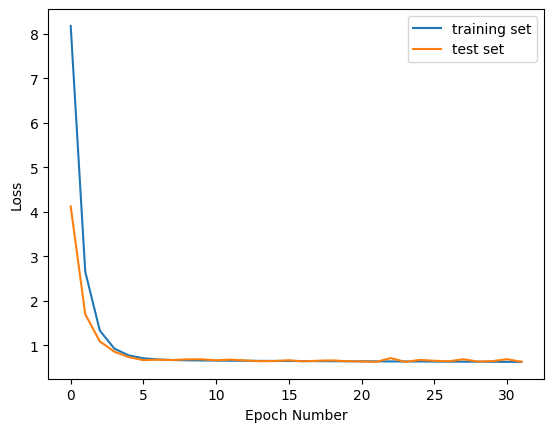

In [23]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

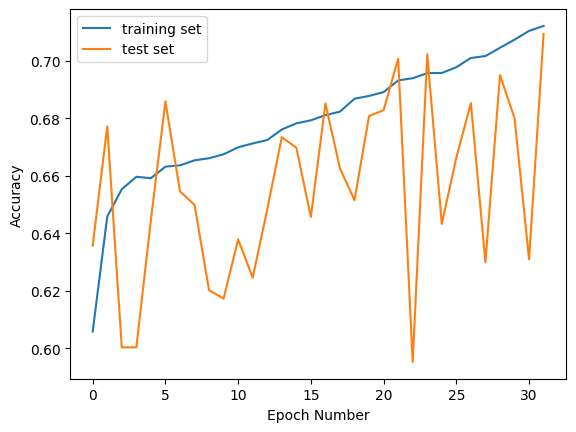

In [24]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

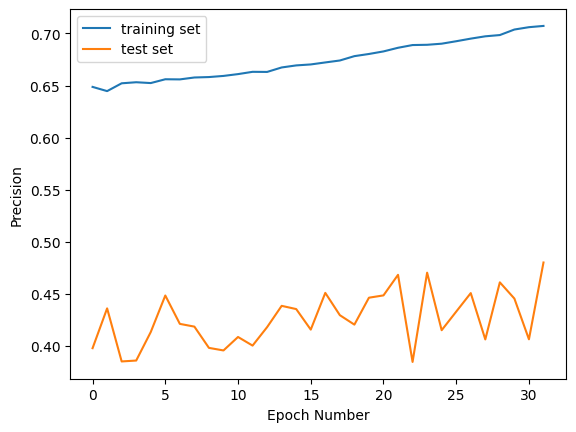

In [25]:
plt.xlabel('Epoch Number')
plt.ylabel('Precision')
plt.plot(training_history.history['precision'], label='training set')
plt.plot(training_history.history['val_precision'], label='test set')
plt.legend()

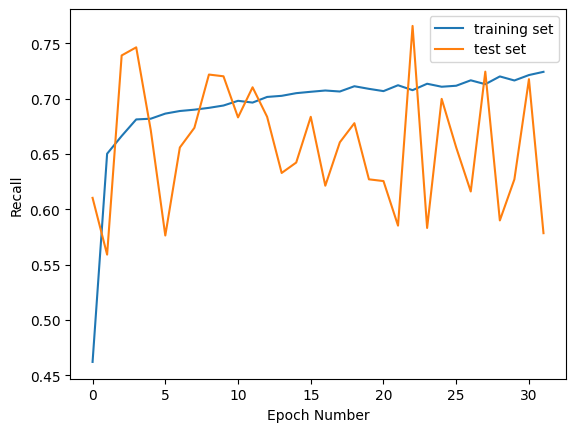

In [26]:
plt.xlabel('Epoch Number')
plt.ylabel('Recall')
plt.plot(training_history.history['recall'], label='training set')
plt.plot(training_history.history['val_recall'], label='test set')
plt.legend()

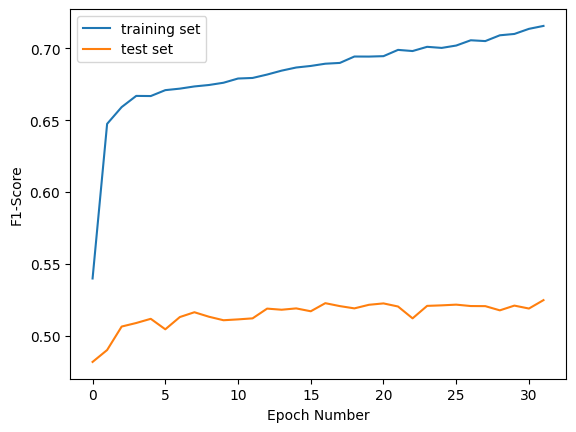

In [27]:
plt.xlabel('Epoch Number')
plt.ylabel('F1-Score')
plt.plot(training_history.history['f1_score'], label='training set')
plt.plot(training_history.history['val_f1_score'], label='test set')
plt.legend()

## Model performance

In [28]:
def print_metrics(score: np.ndarray, is_train: bool) -> None:
    split = "Train" if is_train else "Test"
    print(f"{split} loss: {score[0]}")
    print(f"{split} accuracy: {score[1]}")
    print(f"{split} precision: {score[2]}")
    print(f"{split} recall: {score[3]}")
    print(f"{split} f1-score: {score[4]}")

In [29]:
train_score = model.evaluate(x_train, y_train)
print_metrics(train_score, is_train=True)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.6957 - f1_score: 0.6773 - loss: 0.6383 - precision: 0.7210 - recall: 0.6386
Train loss: 0.6382767558097839
Train accuracy: 0.6957054734230042
Train precision: 0.7209538817405701
Train recall: 0.6385704874992371
Train f1-score: [0.677266]


In [30]:
test_score = model.evaluate(x_test, y_test)
print_metrics(test_score, is_train=False)

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.7007 - f1_score: 0.5202 - loss: 0.6288 - precision: 0.4682 - recall: 0.5853
Test loss: 0.6288295984268188
Test accuracy: 0.7007394433021545
Test precision: 0.46820083260536194
Test recall: 0.5852510333061218
Test f1-score: [0.520223]


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step


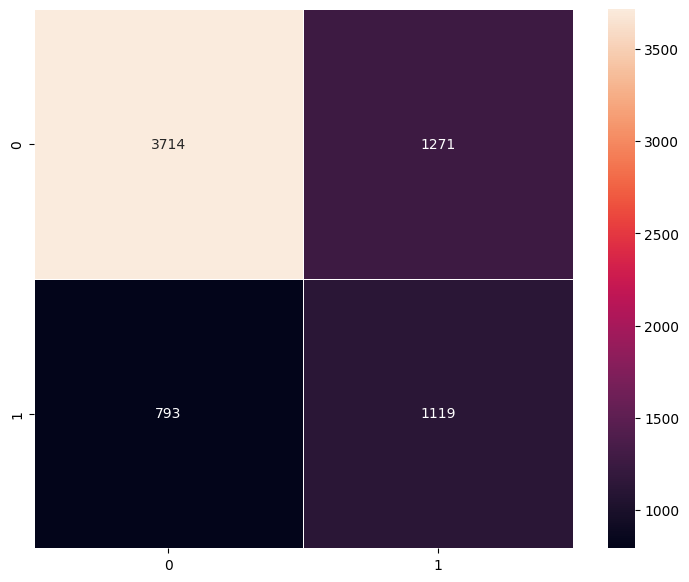

In [31]:
confusion_matrix = tf.math.confusion_matrix(y_test.T[0], np.round(model.predict(x_test).T[0]))
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

#### K-fold cross validation

In [ ]:
skfold = StratifiedKFold(n_splits=5, shuffle=True)

for i, (train_split, test_split) in enumerate(skfold.split(x, y)):    
    x_train_split = x[train_split]
    x_test_split = x[test_split]
    y_train_split = y[train_split]
    y_test_split = y[test_split]

    x_train_split, y_train_split = smote.fit_resample(x_train_split, y_train_split)
    y_train_split = np.reshape(y_train_split, (-1, 1))
    
    reset_model = models.clone_model(model)
    reset_model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

    reset_model.fit(x_train_split, y_train_split, batch_size=batch_size, epochs=epochs, shuffle=True, 
              callbacks=[early_stop], validation_data=(x_test_split, y_test_split), verbose=0)

    print(f"Fold {i + 1}:")
    
    train_score = reset_model.evaluate(x_train_split, y_train_split)
    print_metrics(train_score, is_train=True)
    print()
    
    test_score = reset_model.evaluate(x_test_split, y_test_split)
    print_metrics(test_score, is_train=False)
    print()

Fold 1:
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.6660 - f1_score: 0.6262 - loss: 0.6605 - precision: 0.7109 - recall: 0.5596
Train loss: 0.6604838967323303
Train accuracy: 0.6660157442092896
Train precision: 0.7108962535858154
Train recall: 0.559611439704895
Train f1-score: [0.62624675]

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - accuracy: 0.7028 - f1_score: 0.5055 - loss: 0.6275 - precision: 0.4674 - recall: 0.5504
Test loss: 0.6274806261062622
Test accuracy: 0.7027693390846252
Test precision: 0.46743980050086975
Test recall: 0.5504201650619507
Test f1-score: [0.5055475]

Fold 2:
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.6750 - f1_score: 0.6288 - loss: 0.6499 - precision: 0.7328 - recall: 0.5507
Train loss: 0.6499007940292358
Train accuracy: 0.6749536991119385
Train precision: 0.7328091859817505
Train recall: 0.5506985187530518
Train f1-score: [0.6288344]

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - accuracy: 0.7219 - f1_score: 0.5046 - loss: 0.61

## Conclusion

Using a rather simple MLP model proved to be more effective than the previously used CNN, achieving good validation results with F1 scores rounding 0.5. It's possible that the quality level of the new dataset has increased compared to the previously used one. However, the problem remains of high difficulty, where our model still shows poor predictive performance.